I define all the constants I need below

In [6]:

using Combinatorics
using Arpack
using Combinatorics
using LinearAlgebra
using Plots
using Random


include("operators.jl")

flux=π
scale=1.0
am=4*π/(√3*scale);
β=4*flux/(√3*scale^2)

mass=0.5;
V0=0
ϕ=0.0;



b1=4*π/(√3*am)*[0,1]
b2=4*π/(√3*am)*[√3/2,1/2]


a1m=am*[-1/2,√3/2]
a2m=am*[1,0]

Nq=6;
T1=b1/(Nq)
T2=b2/(Nq)
constq=0/Nq^2

mpoint=1/2*b1;
γ=[0,0];
Kp=1/3*(b1+b2);

Npath=60
Nsec=20
qpath=Matrix{Float64}(undef,2,Npath)
for ja in 1:Nsec
    qpath[:,ja]=γ*(1-ja/Nsec)+mpoint*ja/Nsec
    qpath[:,ja+Nsec]=mpoint*(1-ja/Nsec)+Kp*ja/Nsec
    qpath[:,ja+2*Nsec]=Kp*(1-ja/Nsec)+γ*ja/Nsec
end


b1T=Int.(round.(inv([T1 T2])*b1))
b2T=Int.(round.(inv([T1 T2])*b2))

#=allowedq=Vector{Int64}[]
for ja in 1:Nq,jb in 1:Nq
    push!(allowedq,[2*ja-Nq-1,2*jb-Nq-1])
end

Coulmesh=Vector{Int64}[]
for ja in 0:Nq-1,jb in 0:Nq-1
    push!(Coulmesh,[2*ja,2*jb])
end
=#


allowedq=Vector{Int64}[]
for ja in 0:Nq-1,jb in 0:Nq-1
    push!(allowedq,[ja,jb])
end



wave=Vector{Int64}[]
cutoff=18
cutoffstandard=5.01*4*π/(√3*am)
for ja in -cutoff:cutoff, jb in -cutoff:cutoff
    gtest=ja*b1+jb*b2;
    if (gtest[1]^2+gtest[2]^2)<cutoffstandard^2
        push!(wave,ja*b1T+jb*b2T)
    end
end
dimension=length(wave)
println(length(wave))



overlapmatrix=zeros(ComplexF64,Nq^2,length(wave),Nq^2,length(wave))
for ja in 1:Nq^2, jb in eachindex(wave), jc in 1:Nq^2, jd in eachindex(wave)
   overlapmatrix[ja,jb,jc,jd]=overlap([T1 T2]*(allowedq[ja]+wave[jb]),[T1 T2]*(allowedq[jc]+wave[jd]-wave[jb]-allowedq[ja]),β)
end




91


In [7]:
single_Ham=[zeros(ComplexF64,dimension,dimension) for ja in 1:Nq^2]
single_MoirePo=[zeros(ComplexF64,dimension,dimension) for ja in 1:Nq^2]
single_eigenvalue=zeros(dimension,Nq^2)
single_eigenvector=[zeros(ComplexF64,dimension,dimension) for ja in 1:Nq^2]


for ja in 1:Nq^2
  
  
  k=allowedq[ja][1]*T1+allowedq[ja][2]*T2

  for jb in eachindex(wave)
   single_Ham[ja][jb,jb]=norm(k+wave[jb][1]*T1+wave[jb][2]*T2)^2/(2*mass)
  end
  
 for jc in eachindex(wave)
    k1=k+wave[jc][1]*T1+wave[jc][2]*T2
    pos=findfirst(item->item==wave[jc]-b1T,wave)
    if pos≠nothing
      single_MoirePo[ja][jc,pos]=V0*exp(im*ϕ)*overlap(k1,-b1,β)
    end
    
  
    pos=findfirst(item->item==wave[jc]-b2T+b1T,wave)
    if pos≠nothing
        single_MoirePo[ja][jc,pos]=V0*exp(im*ϕ)*overlap(k1,-b2+b1,β)
    end

    pos=findfirst(item->item==wave[jc]+b2T,wave)
    if pos≠nothing
        single_MoirePo[ja][jc,pos]=V0*exp(im*ϕ)*overlap(k1,b2,β)
    end
 end

 single_MoirePo[ja]=single_MoirePo[ja]+single_MoirePo[ja]'
 FFF=eigen(single_MoirePo[ja]+single_Ham[ja])

  single_eigenvalue[:,ja]=real(FFF.values)
  single_eigenvector[ja]=FFF.vectors

end

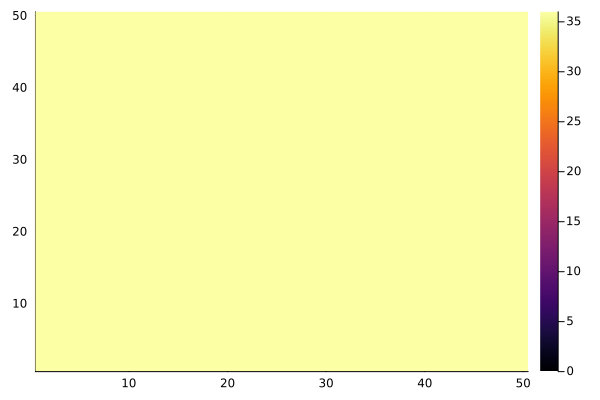

In [8]:
input_DensityMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
for ja in 1:Nq^2
 
   input_DensityMatrix[ja]+=(single_eigenvector[ja][:,1]*(single_eigenvector[ja][:,1])')
    
end


N3=50
single_xgrid=zeros(Float64,N3,N3)
single_ygrid=zeros(Float64,N3,N3)
single_zgrid=zeros(ComplexF64,N3,N3)
Hartree_Density=zeros(ComplexF64,dimension,dimension)
  for jk1 in 1:Nq^2
   Hartree_Density+=input_DensityMatrix[jk1] .* transpose(overlapmatrix[jk1,:,jk1,:])
  end

for ja in 1:50, jb in 1:50
  single_xgrid[ja,jb]=(ja/25*a1m[1]+jb/25*a2m[1])
  single_ygrid[ja,jb]=(ja/25*a1m[2]+jb/25*a2m[2])
  rvec=ja/25*a1m+jb/25*a2m
  for jc in eachindex(wave), jd in eachindex(wave)
    gvec=[T1 T2]*(wave[jc]-wave[jd])
   single_zgrid[ja,jb]+=Hartree_Density[jc,jd]*exp(im*(gvec[1]*rvec[1]+gvec[2]*rvec[2]))
  end

end
myplot=heatmap(real.(single_zgrid))
display(myplot)






#=for ja in 1:Nq^2
  A=randn(ComplexF64,dimension,dimension)
  input_DensityMatrix[ja]=0.9*input_DensityMatrix[ja]+(A+A')*0.001
end
=#


#random_DensityMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
##   filled=rand(1:dimension)
  # random_DensityMatrix[ja][jb,jc]+=single_eigenvector[ja][:,filled]*(single_eigenvector[ja][:,filled])'
   
#end

#input_DensityMatrix=0.9*input_DensityMatrix+0.1*random_DensityMatrix


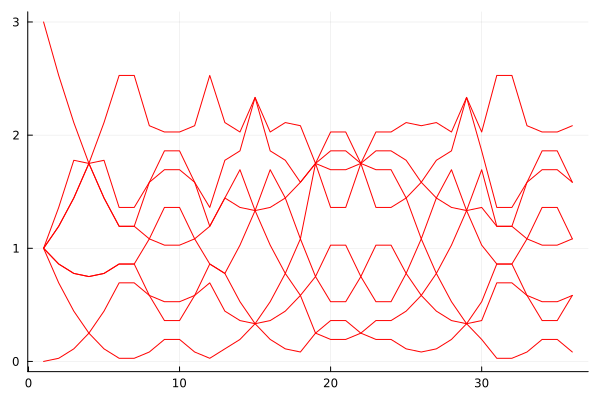

In [9]:
NOHF_pathvalue=zeros(Float64,dimension,Nq^2)
for ja in 1:Nq^2
    NOHF_pathvalue[:,ja]=real(eigvals(single_Ham[ja]+single_MoirePo[ja]))
end 

myplot=plot()
plot!(1:Nq^2,Float64.(NOHF_pathvalue[1:8,:]'),legend=false,color="red")

display(myplot)

In [10]:
using JLD2
jldsave("DensityMatrix_nopotential.jld2",densitymatrix=input_DensityMatrix)

In [4]:
g_dic=Dict{Vector{Int},Int}()
for ja in eachindex(wave)
  g_dic[wave[ja]]=ja
end

In [5]:
loop_dic=Dict{Vector{Int},Any}()

for gindex in eachindex(wave), g2index in eachindex(wave)
    if !haskey(loop_dic,wave[g2index]-wave[gindex])
       loop_dic[wave[g2index]-wave[gindex]]=Dict{Vector{Int},Vector{Vector{Int}}}()
    end
    
    loop_dic[wave[g2index]-wave[gindex]][[gindex,g2index]]=Vector{Int64}[]
    
     
end

for gindex in eachindex(wave), g1index in eachindex(wave),g2index in eachindex(wave)
    if haskey(g_dic,wave[gindex]+wave[g1index]-wave[g2index])
        push!(loop_dic[wave[g2index]-wave[gindex]][[gindex,g2index]],[g1index,g_dic[wave[gindex]+wave[g1index]-wave[g2index]]])
    end
end



In [6]:
include("operators.jl")
eout=1.0
itcount=0

DeltaMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
DIIS_input_DensityMatrix=Vector{Vector{Matrix{ComplexF64}}}(undef,3)
DIIS_input_DeltaMatrix=Vector{Vector{Matrix{ComplexF64}}}(undef,3)

while eout>10^-6

 tic=time()
  eout,output_DensityMatrix,DeltaMatrix,_=Construct_DensityMatrix(loop_dic,allowedq,T1,T2,Nq,wave,input_DensityMatrix,single_Ham,single_MoirePo,constq,overlapmatrix)
  DIIS_input_DensityMatrix[mod(itcount,3)+1]=input_DensityMatrix
  DIIS_input_DeltaMatrix[mod(itcount,3)+1]=DeltaMatrix
  input_DensityMatrix=output_DensityMatrix
  itcount+=1
 toc=time()
 println(toc-tic,"eout=$eout")

end





7.828000068664551eout=0.005360273914568039


6.680999994277954eout=0.001474538451645636


6.815000057220459eout=0.000406226194599213


6.802000045776367eout=0.00011206952273025344


6.8999998569488525eout=3.0958561206410984e-5


6.866000175476074eout=8.56277776415164e-6


6.827999830245972eout=2.3711420532786336e-6


6.757000207901001eout=6.573236235809456e-7


We now start DIIS

In [7]:
HF_eigenvalue=Vector{Any}(undef,Nq^2)

while eout>10^-14
    tic=time()
    Bmatrix=zeros(ComplexF64,4,4)
    for ja in 1:3
     Bmatrix[ja,4]=1
     Bmatrix[4,ja]=1
    end

    for ja in 1:3,jb in 1:3
        for jc in 1:Nq^2
           Bmatrix[ja,jb]+=tr((DIIS_input_DeltaMatrix[ja][jc])'*(DIIS_input_DeltaMatrix[jb][jc]))
        end
    end
    coeff=inv(Bmatrix)*[0;0;0;1]
    input_DensityMatrix=coeff[1]*(DIIS_input_DensityMatrix[1]+DIIS_input_DeltaMatrix[1])+coeff[2]*(DIIS_input_DensityMatrix[2]+DIIS_input_DeltaMatrix[2])+coeff[3]*(DIIS_input_DensityMatrix[3]+DIIS_input_DeltaMatrix[3])
    eout,output_DensityMatrix,DeltaMatrix,HF_eigenvalue=Construct_DensityMatrix(loop_dic,allowedq,T1,T2,Nq,wave,input_DensityMatrix,single_Ham,single_MoirePo,constq,overlapmatrix)
    DIIS_input_DensityMatrix[mod(itcount,3)+1]=input_DensityMatrix
    DIIS_input_DeltaMatrix[mod(itcount,3)+1]=DeltaMatrix
    itcount+=1
    toc=time()
    println(toc-tic,"eout=$eout")
end

6.849999904632568eout=1.1087489868991618e-16


In [8]:
NOHF_pathvalue=zeros(Float64,dimension,Nq^2)
HF_pathvalue=zeros(Float64,dimension,Nq^2)
for ja in 1:Nq^2
    NOHF_pathvalue[:,ja]=real(eigvals(single_Ham[ja]+single_MoirePo[ja]))
    HF_pathvalue[:,ja]=real(HF_eigenvalue[ja])
end 

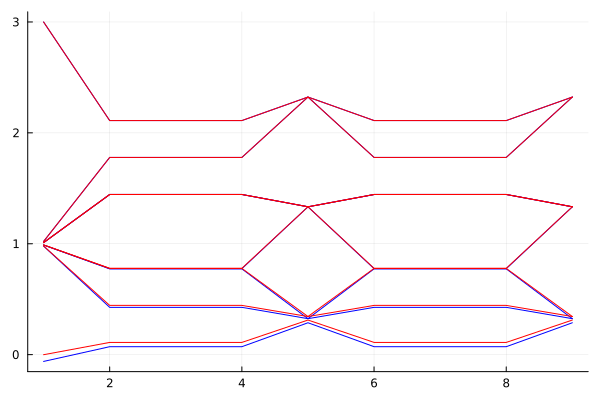

In [9]:

myplot=plot()

plot!(1:Nq^2,Float64.(HF_pathvalue[1:8,:]'),legend=false,color="blue")
plot!(1:Nq^2,Float64.(NOHF_pathvalue[1:8,:]'),legend=false,color="red")

display(myplot)


Let us calculate the charge density below

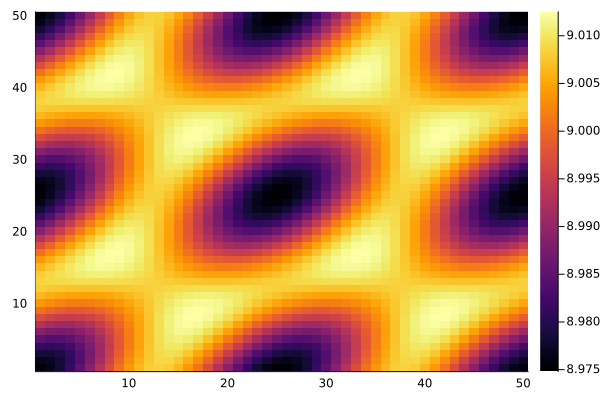

In [10]:
N3=50
xgrid=zeros(Float64,N3,N3)
ygrid=zeros(Float64,N3,N3)
zgrid=zeros(ComplexF64,N3,N3)
Hartree_Density=zeros(ComplexF64,dimension,dimension)
  for jk1 in 1:Nq^2
   Hartree_Density+=input_DensityMatrix[jk1] .* transpose(overlapmatrix[jk1,:,jk1,:])
  end

for ja in 1:50, jb in 1:50
  xgrid[ja,jb]=(ja/25*a1m[1]+jb/25*a2m[1])
  ygrid[ja,jb]=(ja/25*a1m[2]+jb/25*a2m[2])
  rvec=ja/25*a1m+jb/25*a2m
  for jc in eachindex(wave), jd in eachindex(wave)
    gvec=[T1 T2]*(wave[jc]-wave[jd])
   zgrid[ja,jb]+=Hartree_Density[jc,jd]*exp(im*(gvec[1]*rvec[1]+gvec[2]*rvec[2]))
  end

end
myplot=heatmap(real.(zgrid))
display(myplot)

Let us just calculate the Chern number on the grid we defined

In [11]:
chern_allowedq=Vector{Int64}[]
for ja in 0:Nq,jb in 0:Nq
    push!(chern_allowedq,[ja,jb])
end

chern_overlapmatrix=zeros(ComplexF64,(Nq+1)^2,length(wave),(Nq+1)^2,length(wave))
for ja in 1:(Nq+1)^2, jb in eachindex(wave), jc in 1:(Nq+1)^2, jd in eachindex(wave)
   chern_overlapmatrix[ja,jb,jc,jd]=overlap([T1 T2]*(chern_allowedq[ja]+wave[jb]),[T1 T2]*(chern_allowedq[jc]+wave[jd]-wave[jb]-chern_allowedq[ja]),β)
end


eigenvector_bc=zeros(ComplexF64,dimension,Nq+1,Nq+1)
for ja in eachindex(chern_allowedq)
    k=[T1 T2]*chern_allowedq[ja]
    chern_Ham=zeros(ComplexF64,dimension,dimension)
    chern_MoirePo=zeros(ComplexF64,dimension,dimension)
    for jb in eachindex(wave)
        chern_Ham[jb,jb]=norm(k+wave[jb][1]*T1+wave[jb][2]*T2)^2/(2*mass)
    end

    for jc in eachindex(wave)
        k1=k+wave[jc][1]*T1+wave[jc][2]*T2
        pos=findfirst(item->item==wave[jc]-b1T,wave)
        if pos≠nothing
       chern_MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-b1,β)
        end
        
      
        pos=findfirst(item->item==wave[jc]-b2T+b1T,wave)
        if pos≠nothing
            chern_MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-b2+b1,β)
        end
    
        pos=findfirst(item->item==wave[jc]+b2T,wave)
        if pos≠nothing
            chern_MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,b2,β)
        end
     end
    
  chern_MoirePo=chern_MoirePo+chern_MoirePo'
  HFmatrix=Construct_HFmatrix(loop_dic,ja,chern_allowedq[ja],allowedq,T1,T2,Nq,wave,DIIS_input_DensityMatrix[1],constq,chern_overlapmatrix)
  eigenvector_bc[:,chern_allowedq[ja][1]+1,chern_allowedq[ja][2]+1]=eigvecs(chern_Ham+chern_MoirePo+HFmatrix)[:,1] 

end


Uonelink=zeros(ComplexF64,Nq,Nq+1)
Utwolink=zeros(ComplexF64,Nq+1,Nq)

for ja in 1:Nq, jb in 1:Nq+1
    Amatrix=metric(wave,β,(ja-1)*T1+(jb-1)*T2,T1,T1,T2)
   Uonelink[ja,jb]=dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja+1,jb])/abs(dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja+1,jb]))
end

for ja in 1:Nq+1, jb in 1:Nq
    Amatrix=metric(wave,β,(ja-1)*T1+(jb-1)*T2,T2,T1,T2)
 Utwolink[ja,jb]=dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja,jb+1])/abs(dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja,jb+1]))
end

Flink=zeros(ComplexF64,Nq,Nq)
for ja in 1:Nq, jb in 1:Nq
 Flink[ja,jb]=log(Uonelink[ja,jb]*Utwolink[ja+1,jb]/(Uonelink[ja,jb+1]*Utwolink[ja,jb]))
end
chern=sum(Flink)/(2*π*im)



3.0000000000000013 + 3.754821498949988e-17im

In [14]:
println(Flink)

ComplexF64[-1.2490009027033014e-16 + 2.0943951023931953im -1.5265566588595905e-16 + 2.0943951023931953im 3.0531133177191795e-16 + 2.0943951023931957im; -1.1102230246251565e-16 + 2.0943951023931957im 2.7755575615628914e-17 + 2.0943951023931957im -3.0531133177191815e-16 + 2.0943951023931957im; 9.714451465470118e-17 + 2.0943951023931957im -8.326672684688675e-17 + 2.0943951023931966im 1.1102230246251564e-16 + 2.0943951023931953im]


In [12]:
#=e1=1.0
while e1>10^-8

   HartreeMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
   FockMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]

  
   for jk in 1:Nq^2
     k=allowedq[jk][1]*T1+allowedq[jk][2]*T2
     for jk1 in 1:Nq^2
        k1=allowedq[jk1][1]*T1+allowedq[jk1][2]*T2
        for dg in keys(loop_dic)
            dgvec=[T1 T2]*dg#dgvec is g2-g
            CoulF1=Coulomb(allowedq[jk1]-allowedq[jk]+dg,T1,T2)
            CoulH1=Coulomb(dg,T1,T2)
            for gg2 in keys(loop_dic[dg])
                g2=[T1 T2]*wave[gg2[2]]
                CoulH=CoulH1*overlap(k+g2,-dgvec,β)
                CoulF=CoulF1*overlap(k1+g2,k-dgvec-k1,β)
            for g1g3 in loop_dic[dg][gg2]
                g3=[T1 T2]*wave[g1g3[2]]
                FockMatrix[jk][g1g3[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],gg2[2]]*CoulF*overlap(k+g3,k1+dgvec-k,β)
                HartreeMatrix[jk][gg2[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],g1g3[2]]*CoulH*overlap(k1+g3,dgvec,β)
           
            
            end 
            end
    
        end    
     end
   end

  for ja in 1:Nq^2
    FFF=eigen(single_MoirePo[ja]+single_Ham[ja]+constq*HartreeMatrix[ja]-constq*FockMatrix[ja])
    HF_eigenvalue[ja]=real(FFF.values)
    HF_eigenvector[ja]=FFF.vectors
    
  end

  bound=sort(reduce(vcat,HF_eigenvalue))[Nq^2+1]
  filling=zeros(Float64,Nq^2,dimension)
  NewDensityMatrix=[zeros(ComplexF64,dimension,dimension) for _ in 1:Nq^2]
   for ja in 1:Nq^2
     
        for jd in eachindex(HF_eigenvalue[ja])
           if HF_eigenvalue[ja][jd]<bound
              NewDensityMatrix[ja]+=HF_eigenvector[ja][:,jd]*(HF_eigenvector[ja][:,jd])'
           end
        end
  
   end

   
    for ja in 1:Nq^2
      DeltaMatrix[ja]=NewDensityMatrix[ja]-input_DensityMatrix[ja]
    end

   e1=0.0
   for ja in 1:Nq^2
     e1+=tr(DeltaMatrix[ja]'*DeltaMatrix[ja])
   end
   e1=real(e1)
   println(e1)
  
 for ja in 1:Nq^2
    input_DensityMatrix[ja]=0.5*input_DensityMatrix[ja]+0.5*NewDensityMatrix[ja]
 end
end
=#

 


In [13]:
#=
for jk in 1:Nq^2
    #k=allowedq[jk][1]*T1+allowedq[jk][2]*T2
    for jk1 in 1:Nq^2
       #k1=allowedq[jk1][1]*T1+allowedq[jk1][2]*T2
       for dg in keys(loop_dic)
           #dgvec=[T1 T2]*dg#dgvec is g2-g
           CoulF1=Coulomb(allowedq[jk1]-allowedq[jk]+dg,T1,T2)
           CoulH1=Coulomb(dg,T1,T2)
           for gg2 in keys(loop_dic[dg])
               #g2=[T1 T2]*wave[gg2[2]]
               #CoulH=CoulH1*overlap(k+g2,-dgvec,β)
               CoulH=CoulH1*overlapmatrix[jk,gg2[2],jk,gg2[1]]
               #CoulF=CoulF1*overlap(k1+g2,k-dgvec-k1,β)
               CoulF=CoulF1*overlapmatrix[jk1,gg2[2],jk,gg2[1]]
           for g1g3 in loop_dic[dg][gg2]
               g3=[T1 T2]*wave[g1g3[2]]
               #FockMatrix[jk][g1g3[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],gg2[2]]*CoulF*overlap(k+g3,k1+dgvec-k,β)
               #HartreeMatrix[jk][gg2[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],g1g3[2]]*CoulH*overlap(k1+g3,dgvec,β)
               FockMatrix[jk][g1g3[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],gg2[2]]*CoulF*overlapmatrix[jk,g1g3[2],jk1,g1g3[1]]
               HartreeMatrix[jk][gg2[2],gg2[1]]+=input_DensityMatrix[jk1][g1g3[1],g1g3[2]]*CoulH*overlapmatrix[jk1,g1g3[2],jk1,g1g3[1]]
          
           
           end 
           end
   
       end    
    end
  end
  =#